In [56]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
import random

from shapely.geometry import Polygon

In [34]:
auto_link_gdf = gpd.read_file('replica-auto-network_link_layer.geojson')
bike_link_gdf = gpd.read_file('replica-bike-network_link_layer.geojson')

In [35]:
### Area of Interest for Project Prompt ###
# this is copy & pasted from Lat-Lon format in Google Maps
top_left = (38.543713558227566, -121.74398135752226)
top_right = (38.5445375416281, -121.73808167850387)
bottom_right = (38.54326410875721, -121.73750703444362)
bottom_left = (38.54215545472125, -121.7445751563845)

def ll_to_xy(ll):
    return (ll[1], ll[0])  # (lat,lon) -> (lon,lat)

# Create initial AOI polygon (lon,lat)
aoi_poly = Polygon([
    ll_to_xy(top_left),
    ll_to_xy(top_right),
    ll_to_xy(bottom_right),
    ll_to_xy(bottom_left),
    ll_to_xy(top_left),
])

# Put AOI into a GeoDataFrame with WGS84 CRS
aoi = gpd.GeoDataFrame({'geometry':[aoi_poly]}, crs='EPSG:4326')

# Buffer the AOI by 0.5 mile (approx 804.672 meters):
# - project to a metric CRS (Web Mercator EPSG:3857), buffer in meters, then reproject back
aoi_proj = aoi.to_crs(epsg=3857)
buffer_m = 0 * 1609.344  # 0.5 mile in meters
aoi_buffered_proj = aoi_proj.buffer(buffer_m)
aoi = gpd.GeoDataFrame(geometry=aoi_buffered_proj, crs='EPSG:3857').to_crs(epsg=4326)

# Now `aoi` contains the buffered polygon in EPSG:4326

<Figure size 1000x1000 with 0 Axes>

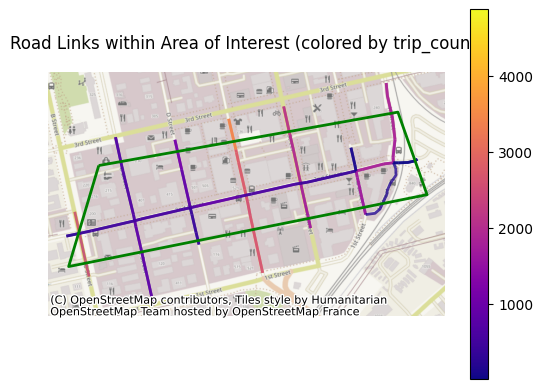

In [36]:
# Spatial join: keep only links that intersect the AOI
auto_links_in_aoi = gpd.sjoin(auto_link_gdf, aoi, how="inner", predicate="intersects")

# Reproject to Web Mercator (EPSG:3857) for contextily basemap plotting
links_plot = auto_links_in_aoi.to_crs(epsg=3857)
aoi_plot = aoi.to_crs(epsg=3857)
residential_aoi_links = links_plot[
    (links_plot["highway"] == "residential")
    | (links_plot["highway"] == "tertiary")
    | (links_plot["highway"] == "secondary")
]

# Plot links colored by trip_count with AOI boundary and basemap
plt.figure(figsize=(10, 10))
ax = residential_aoi_links.plot(
    column="trip_count", cmap="plasma", legend=True, alpha=0.8, linewidth=2
)
aoi_plot.boundary.plot(ax=ax, color="green", linewidth=2)
ctx.add_basemap(ax, crs="EPSG:3857")
ax.set_title("Road Links within Area of Interest (colored by trip_count)")
ax.set_axis_off()
plt.show()


In [67]:
link_weights = residential_aoi_links.groupby(["roadName", "direction"]).agg(
    {"trip_count": "sum"}
).sort_values(by="trip_count", ascending=False)

trip_count_random_hour = round(link_weights \
    * random.uniform(0.08, 0.12)
)
trip_count_random_hour

trip_count
roadName   direction            
E Street   South          2020.0
           North          1859.0
F Street   South          1625.0
           North          1405.0
B Street   South          1238.0
2nd Street East           1218.0
           West           1205.0
B Street   North           557.0
H Street   North           479.0
           South           454.0
G Street   South           444.0
           North           441.0
C Street   South           397.0
           North           383.0
D Street   North           347.0
           South           332.0
H Street   NorthEast        17.0

In [62]:
random.uniform(0.08, 0.12)

0.11489834440103475